## Project 4: Car price prediction

Training a model to predict the price of the car.

In [169]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [170]:
# 1. Load Data
df = pd.read_csv("car_price_details.csv")

In [171]:
# 2. Encode categorical features
fuel_map = {"Diesel":0, "Petrol":1, "CNG":2, "LPG":3, "Electric":4}
seller_map = {"Individual":0, "Dealer":1, "Trustmark Dealer":2}
transmission_map = {"Manual":0, "Automatic":1}
owner_map = {"First Owner":0, "Second Owner":1, "Third Owner":2, "Fourth & Above Owner":3, "Test Drive Car":4}

In [172]:
# Apply mappings
df["fuel"] = df["fuel"].map(fuel_map)
df["seller_type"] = df["seller_type"].map(seller_map)
df["transmission"] = df["transmission"].map(transmission_map)
df["owner"] = df["owner"].map(owner_map)

In [173]:
# Encode name using target encoding
name_price_map = df.groupby('name')['selling_price'].mean().to_dict()
df['name_encoded'] = df['name'].map(name_price_map)
df.drop(columns=['name'], inplace=True)

In [174]:
# Feature engineering
df['vehicle_age'] = 2025 - df['year']  # assuming current year is 2025
# Optional: log-transform km driven
# df['km_driven'] = np.log1p(df['km_driven'])

In [175]:
# 3. Define features and target
features = ['vehicle_age', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'name_encoded']
X = df[features].values
y = df['selling_price'].values.reshape(-1, 1)

In [176]:
# 4. Feature & Target Scaling
scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)

In [177]:
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

In [178]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [179]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [180]:
# 6. Define the model
class VehiclePricePredictor(nn.Module):
    def __init__(self, input_size=7):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Softplus()  # Ensure positive output
        )

    def forward(self, x):
        return self.model(x)

In [181]:
model = VehiclePricePredictor(input_size=X.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [182]:
# 7. Training Loop with Early Stopping
best_loss = float('inf')
patience = 500
counter = 0
epochs = 5000

In [183]:
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 200 == 0:
        model.eval()
        with torch.no_grad():
            y_test_pred = model(X_test_tensor)
            test_loss = criterion(y_test_pred, y_test_tensor)
            print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

            if test_loss.item() < best_loss:
                best_loss = test_loss.item()
                counter = 0
                torch.save(model.state_dict(), "best_model.pth")
            else:
                counter += 1
            if counter > patience:
                print("Early stopping triggered")
                break

Epoch 200, Train Loss: 0.1746, Test Loss: 0.1785
Epoch 400, Train Loss: 0.1669, Test Loss: 0.1725
Epoch 600, Train Loss: 0.1643, Test Loss: 0.1722
Epoch 800, Train Loss: 0.1620, Test Loss: 0.1749
Epoch 1000, Train Loss: 0.1598, Test Loss: 0.1827
Epoch 1200, Train Loss: 0.1584, Test Loss: 0.1962
Epoch 1400, Train Loss: 0.1571, Test Loss: 0.2005
Epoch 1600, Train Loss: 0.1555, Test Loss: 0.2234
Epoch 1800, Train Loss: 0.1555, Test Loss: 0.2058
Epoch 2000, Train Loss: 0.1547, Test Loss: 0.2263
Epoch 2200, Train Loss: 0.1546, Test Loss: 0.2285
Epoch 2400, Train Loss: 0.1543, Test Loss: 0.2279
Epoch 2600, Train Loss: 0.1542, Test Loss: 0.2344
Epoch 2800, Train Loss: 0.1550, Test Loss: 0.2226
Epoch 3000, Train Loss: 0.1545, Test Loss: 0.2414
Epoch 3200, Train Loss: 0.1539, Test Loss: 0.2340
Epoch 3400, Train Loss: 0.1535, Test Loss: 0.2337
Epoch 3600, Train Loss: 0.1535, Test Loss: 0.2361
Epoch 3800, Train Loss: 0.1534, Test Loss: 0.2336
Epoch 4000, Train Loss: 0.1532, Test Loss: 0.2378
Epoc

In [184]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

VehiclePricePredictor(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Softplus(beta=1.0, threshold=20.0)
  )
)


Final MAE: 193009.11 INR

Sample Predictions:
Actual: ₹890,000 	 Predicted: ₹747,048
Actual: ₹1,900,000 	 Predicted: ₹2,006,006
Actual: ₹900,000 	 Predicted: ₹788,021
Actual: ₹195,000 	 Predicted: ₹504,463
Actual: ₹800,000 	 Predicted: ₹554,625
Actual: ₹580,000 	 Predicted: ₹606,405
Actual: ₹227,000 	 Predicted: ₹504,702
Actual: ₹730,000 	 Predicted: ₹785,738
Actual: ₹183,000 	 Predicted: ₹505,129
Actual: ₹775,000 	 Predicted: ₹750,780


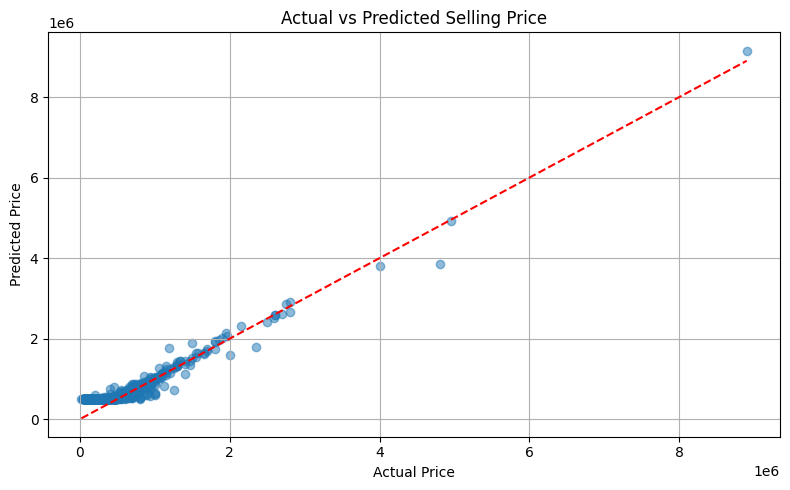

In [185]:
with torch.no_grad():
    predictions_scaled = model(X_test_tensor).numpy()
    predictions = scaler_y.inverse_transform(predictions_scaled)
    y_test_orig = scaler_y.inverse_transform(y_test_tensor.numpy())

    mae = mean_absolute_error(y_test_orig, predictions)
    print(f"\nFinal MAE: {mae:.2f} INR")

    # Print few predictions vs actuals
    import random
    idxs = random.sample(range(len(y_test_orig)), 10)
    print("\nSample Predictions:")
    for i in idxs:
        actual = y_test_orig[i][0]
        predicted = predictions[i][0]
        print(f"Actual: ₹{actual:,.0f} \t Predicted: ₹{predicted:,.0f}")

    # Scatter Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test_orig, predictions, alpha=0.5)
    plt.plot([min(y_test_orig), max(y_test_orig)], [min(y_test_orig), max(y_test_orig)], 'r--')
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title("Actual vs Predicted Selling Price")
    plt.grid(True)
    plt.tight_layout()
    plt.show()